# Self-Attention과 Multi-Head Attention

## 정의

**Attention**은 현재 위치가 여러 입력 위치를 얼마나 참고할지 가중치를 계산하고, 그 가중치로 필요한 정보를 모으는 연산이다. **Self-Attention**은 한 시퀀스 안의 토큰들이 서로를 참고하여 문맥이 반영된 새 토큰 벡터를 만드는 Attention이다.

토큰 임베딩에는 처음에는 해당 토큰 자체의 정보만 들어 있다. Self-Attention을 거치면 각 토큰 벡터에 문장 안의 다른 토큰 정보가 섞이므로, 같은 단어도 주변 문맥에 따라 다른 표현을 가질 수 있다.

## 필요한 이유와 사용처

RNN은 앞에서부터 토큰을 순서대로 처리하지만 Self-Attention은 한 층에서 모든 토큰 쌍의 관계를 계산할 수 있다. 이 구조는 멀리 떨어진 토큰 관계를 직접 연결하고, 여러 위치 계산을 병렬화하는 Transformer의 기반이 된다.

Transformer Encoder의 Self-Attention, Decoder의 Causal Self-Attention, Encoder와 Decoder를 연결하는 Cross-Attention에 같은 핵심 계산이 사용된다.


## 01. Attention이 필요한 이유: 문맥에 따라 참고 대상이 달라진다

아래 원본 이미지는 같은 `it`이라도 문맥에 따라 참고해야 할 단어가 달라지는 상황을 보여 준다.

- `The animal ... because it was too tired.`에서 `it`은 피곤할 수 있는 `animal`을 강하게 참고한다.
- `The animal ... because it was too wide.`에서 `it`은 넓을 수 있는 `street`을 강하게 참고한다.

진한 선은 현재 토큰이 해당 위치를 더 많이 참고한다는 뜻이다. Attention은 단어를 사전 규칙으로 연결하는 기능이 아니라, 학습 과정에서 문맥에 맞는 참고 가중치를 만들도록 파라미터를 조정하는 구조이다.

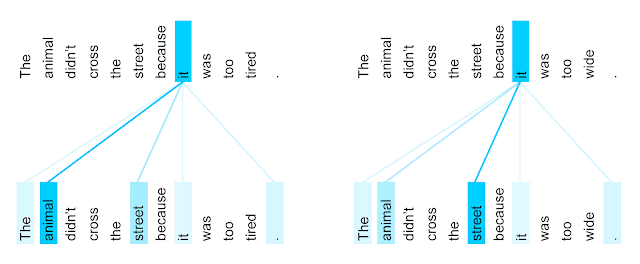

이미지 출처: [TensorFlow Transformer tutorial](https://www.tensorflow.org/text/tutorials/transformer#scaled_dot_product_attention)

이 그림은 Attention이 필요한 이유를 설명하는 예시이며, 아래 수치 코드의 실제 출력 이미지는 아니다. 아래 코드에서는 계산을 읽기 쉽게 한국어 토큰 네 개와 고정 벡터를 사용한다.


## 02. Query, Key, Value는 무엇인가

Attention은 같은 토큰 표현에서 목적이 다른 세 벡터를 만든다. 세 이름은 고정된 단어 종류가 아니라 현재 Attention 계산에서 맡는 역할이다.

- **Query(Q)**: 현재 위치가 어떤 정보를 찾는지 나타내는 질문 벡터
- **Key(K)**: 각 위치가 Query와 관련 있는지 비교할 때 사용하는 색인 벡터
- **Value(V)**: 관련도가 정해진 뒤 실제로 가져와 섞는 내용 벡터

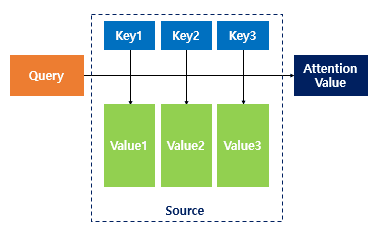

예를 들어 `좋아한다` 위치의 Query는 `나는`, `사과를`, `좋아한다` 위치의 Key와 각각 비교된다. 그 결과 얻은 가중치로 세 위치의 Value를 섞으면 `좋아한다`의 새 문맥 벡터가 만들어진다.

이 원본 그림은 Q·K·V의 역할만 단순화한 구조이며, 중간의 내적 점수·scaling·softmax와 Value 가중합은 생략되어 있다. 생략된 계산은 다음 절의 수식과 코드에서 순서대로 확인한다.

실제 모델은 입력 벡터 `X`에 서로 다른 학습 가중치 $W_Q$, $W_K$, $W_V$를 곱한다.

```text
Q = XW_Q
K = XW_K
V = XW_V
```

따라서 Q·K·V는 원래 토큰 ID가 아니며, 학습 중 값이 바뀌는 선형 투영 결과이다. 아래 직접 계산에서는 Attention 공식 자체를 쉽게 읽기 위해 `Q=K=V=X`로 두지만, 다음 Multi-Head 모듈은 실제 학습 가능한 투영 가중치를 포함한다.

이미지 출처: [원본 교안의 Single-head Attention 이미지](https://d.pr/i/f3W5Zg+)


## 03. Scaled Dot-Product Attention 계산

Query 한 위치가 모든 Key 위치와 얼마나 관련 있는지 내적으로 계산한 뒤, softmax로 가중치를 만들고 Value를 가중합한다.

$$
\operatorname{Attention}(Q,K,V)
=
\operatorname{softmax}\left(
\frac{QK^T}{\sqrt{d_h}} + M
\right)V
$$

- `QK^T`: 모든 Query와 모든 Key의 내적 점수
- $d_h$: head 하나에서 Q와 K가 사용하는 벡터 차원
- $M$: 허용할 Key에는 `0`, 차단할 Key에는 `-∞`를 더하는 mask
- `softmax`: 각 Query가 Key 위치들에 나누어 주는 가중치

계산은 다음 순서로 진행된다.

1. `(B, T, E)`의 Q와 `(B, E, T)`의 $K^T$를 곱해 점수 `(B, T, T)`를 만든다.
2. 점수를 $\sqrt{d_h}$로 나누어 내적값이 지나치게 커지는 것을 완화한다.
3. `<PAD>`처럼 참고하면 안 되는 Key 점수를 `-∞`로 바꾼다.
4. Key 축에 softmax를 적용하여 Query 행마다 합이 1인 가중치를 만든다.
5. 가중치 `(B, T, T)`와 V `(B, T, E)`를 곱해 문맥 벡터 `(B, T, E)`를 만든다.

이어지는 코드에서 `B=1`은 문장 한 개, `T=4`는 토큰 위치 네 개, `E=4`는 토큰별 벡터값 네 개를 뜻한다. 첫 Query인 `나는`의 점수·가중치·새 문맥 벡터를 실제 숫자로 연결한다.

점수 `(B, T, T)`의 두 번째 축은 정보를 모으는 Query 행이고 세 번째 축은 참고할 Key 열이다. 따라서 `scaled_scores[0, 0]`은 첫 문장의 `나는` Query가 `나는·사과를·좋아한다·<PAD>` Key 네 위치에 준 점수 한 행이다.

여기서 Padding mask는 `<PAD>`가 있는 **Key 열**을 차단한다. `<PAD>` Query 행의 출력 자체는 만들어지므로 실제 모델은 손실, pooling 또는 다음 계층에서 해당 위치를 별도로 제외한다.


In [7]:
import math

import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(7)


# 문장 1개, 토큰 4개, 벡터 4  -> (B=1, L=4, E=4)
tokens = ["나는", "사과를", "좋아한다", "<PAD>"]

# tokens를 임베딩 벡터로 변환한 모습
x = torch.tensor(
    [[
        [1.0, 0.0, 1.0, 0.0],
        [0.0, 1.0, 0.0, 1.0],
        [1.0, 1.0, 0.0, 0.0],
        [0.0, 0.0, 0.0, 0.0],  # Padding 자리는 0
    ]]
)

# 공식의 값 변화를 보기 위해 이 예제에서는 Q=K=V=X로 둔다.
query = x
key = x
value = x

# (B=1, L=4, E=4) @ (B=1, E=4, L=4) -> (B=1, L=4, L=4)
raw_scores = query @ key.transpose(-2, -1)
scaled_scores = raw_scores / math.sqrt(query.size(-1))

# 마지막 True는 모든 Query가 <PAD> Key를 참고하지 못하게 한다.
padding_mask = torch.tensor([[False, False, False, True]])

# padding_mask (B, L) -> (B, 1, L)
# -> 모든 Query 행에  -무한(key mask)를 적용
masked_scores = scaled_scores.masked_fill(
    padding_mask.unsqueeze(1),
    float("-inf"),
)

weights_before_mask = F.softmax(scaled_scores, dim=-1)
attention_weights = F.softmax(masked_scores, dim=-1)

# 각 Query의 가중치로 Value 4개를 가중합한 새 토큰 벡터를 생성
context = attention_weights @ value

print("토큰 순서:", tokens)
print("입력 / 출력 shape:", tuple(x.shape), tuple(context.shape))
print("첫 Query의 scaled score:", [round(v, 4) for v in scaled_scores[0, 0].tolist()])
print("첫 Query의 Attention 가중치:", [round(v, 4) for v in attention_weights[0, 0].tolist()])
print("mask 전 / 후 <PAD> 가중치:", round(weights_before_mask[0, 0, -1].item(), 4), "/", attention_weights[0, 0, -1].item())
print("첫 Query 가중치 합:", round(attention_weights[0, 0].sum().item(), 4))
print("'나는'의 새 문맥 벡터:", [round(v, 4) for v in context[0, 0].tolist()])
print("'사과를'의 새 문맥 벡터:", [round(v, 4) for v in context[0, 1].tolist()])
print("'좋아한다'의 새 문맥 벡터:", [round(v, 4) for v in context[0, 2].tolist()])
print("'<PAD>'의 새 문맥 벡터:", [round(v, 4) for v in context[0, 3].tolist()])


토큰 순서: ['나는', '사과를', '좋아한다', '<PAD>']
입력 / 출력 shape: (1, 4, 4) (1, 4, 4)
첫 Query의 scaled score: [1.0, 0.0, 0.5, 0.0]
첫 Query의 Attention 가중치: [0.5065, 0.1863, 0.3072, 0.0]
mask 전 / 후 <PAD> 가중치: 0.1571 / 0.0
첫 Query 가중치 합: 1.0
'나는'의 새 문맥 벡터: [0.8137, 0.4935, 0.5065, 0.1863]
'사과를'의 새 문맥 벡터: [0.4935, 0.8137, 0.1863, 0.5065]
'좋아한다'의 새 문맥 벡터: [0.7259, 0.7259, 0.2741, 0.2741]
'<PAD>'의 새 문맥 벡터: [0.6667, 0.6667, 0.3333, 0.3333]


## 04. Multi-Head Attention

단일 head는 한 종류의 Q·K 비교 공간에서 가중치 한 세트를 만든다.
**Multi-Head Attention**은 전체 임베딩 차원 `E`를 `h`개 head로 나누고, head마다 독립된 투영 가중치로 Attention을 병렬 계산한다.

`E=8`, `h=2`이면 head 하나의 차원은 `d_h=E/h=4`이다.

```text
입력 (B, T, E)
→ Q·K·V 투영
→ head 분할 (B, h, T, d_h)
→ head별 Attention
→ head 연결 (B, T, E)
→ 출력 투영 W_O
→ 최종 출력 (B, T, E)
```

head를 나누는 이유는 모든 head가 반드시 특정 문법 관계를 담당하기 때문이 아니라, 서로 다른 투영 공간에서 여러 관계를 학습할 기회를 주기 위해서이다. head 결과를 단순히 붙이는 것으로 끝나지 않고 $W_O$가 다시 혼합한다.

PyTorch `nn.MultiheadAttention`은 Q·K·V 투영, head 분할, Scaled Dot-Product Attention, head 연결과 $W_O$를 한 모듈 안에서 수행한다. 아래 코드는 아직 학습하지 않은 모듈이므로 가중치 숫자에 문법적 의미를 붙이지 않고, head별 shape와 가중치 합만 확인한다.


In [8]:
embed_dim = 8
num_heads = 2
head_dim = embed_dim // num_heads  # 각 헤드의 차원 == 4

multi_head_attention = nn.MultiheadAttention(
    embed_dim=embed_dim, # 벡터 8개
    num_heads=num_heads, # 헤드 2개
    dropout=0.0,
    batch_first=True,
)

# 문장 2개, 문장마다 토큰 3개, 토큰마다 벡터 8개
# -> 각각 무작위 값을 채워둠(의미 없음)
sample_inputs = torch.randn(2, 3, embed_dim)

# head 평균을 내지 않아 `(B, h, T, T)` 가중치를 확인한다.
with torch.no_grad():
    multi_output, head_weights = multi_head_attention(
        sample_inputs,  # Query
        sample_inputs,  # Key
        sample_inputs,  # Value
        need_weights=True,  # 가중치 반환 할까? True
        average_attn_weights=False,
        # head 별로 attention을 평균 내지 말고 각각 반환
        # -> (B, h, T, T) == (문장=2, head=2, 토큰=3, 헤드별 가중치=3)
    )

print("입력 shape:", tuple(sample_inputs.shape))
print("head 수 / head별 차원:", num_heads, "/", head_dim)
print("head별 가중치 shape:", tuple(head_weights.shape))
print("최종 출력 shape:", tuple(multi_output.shape))
print("W_O 가중치 shape:", tuple(multi_head_attention.out_proj.weight.shape))
print("첫 문장·첫 Query의 head별 가중치:", [
    [round(v, 4) for v in row.tolist()]
    for row in head_weights[0, :, 0]
])
print("첫 문장·첫 Query의 head별 가중치 합:", head_weights[0, :, 0].sum(dim=-1))


입력 shape: (2, 3, 8)
head 수 / head별 차원: 2 / 4
head별 가중치 shape: (2, 2, 3, 3)
최종 출력 shape: (2, 3, 8)
W_O 가중치 shape: (8, 8)
첫 문장·첫 Query의 head별 가중치: [[0.1736, 0.1788, 0.6476], [0.3533, 0.2998, 0.3469]]
첫 문장·첫 Query의 head별 가중치 합: tensor([1., 1.])


## 05. Transformer 안에서 Attention을 구분하는 방법

세 Attention은 계산 공식이 완전히 다른 것이 아니라 **Q가 어디에서 오고 K·V가 어디에서 오는지**, 그리고 미래를 가리는지가 다르다.

### Encoder Self-Attention

source 표현이 Q·K·V를 모두 제공한다. source의 각 토큰이 같은 source 안의 다른 토큰을 참고하여 문맥 벡터를 만든다.

```text
Q = source, K = source, V = source
```

### Decoder Causal Self-Attention

target 표현이 Q·K·V를 모두 제공하는 Self-Attention이지만, 현재 위치보다 뒤의 미래 target을 Causal mask로 가린다. GPT의 다음 토큰 예측에도 이 방식이 사용된다.

```text
Q = target, K = target, V = target
QK^T 점수에서 현재 위치보다 뒤의 Key 열을 Causal mask로 차단
```

### Cross-Attention

Decoder의 target 표현이 Query를 제공하고 Encoder의 `memory`가 Key와 Value를 제공한다. Decoder가 현재 출력에 필요한 source 정보를 가져오는 연결이다.

```text
Q = target, K = encoder memory, V = encoder memory
```

Padding mask는 `<PAD>`처럼 내용이 없는 Key를 가리고, Causal mask는 아직 공개되지 않은 미래 Key를 가린다. 다음 Transformer 교안에서는 이 세 Attention이 Encoder와 Decoder의 어느 층에 배치되는지 전체 구조 안에서 확인한다.


## 06. 전체 정리

Attention은 Query와 Key의 관련도를 계산한 뒤 그 가중치로 Value를 모아 새 문맥 벡터를 만든다. 입력 토큰 벡터가 그대로 복사되는 것이 아니라, 여러 위치의 정보가 가중합되어 같은 shape의 새 값이 만들어진다.

아래 그림은 왼쪽에서 오른쪽으로 읽는다.

1. Query·Key·Value가 각각 무엇을 찾고, 비교하고, 가져오는지 구분한다.
2. $QK^T$ 점수를 $\sqrt{d_h}$로 나누고 mask로 허용하지 않는 Key를 차단한다.
3. Key 축 softmax로 가중치를 만든 뒤 Value를 가중합한다.
4. Multi-Head에서는 head별 계산을 연결하고 $W_O$로 다시 혼합한다.

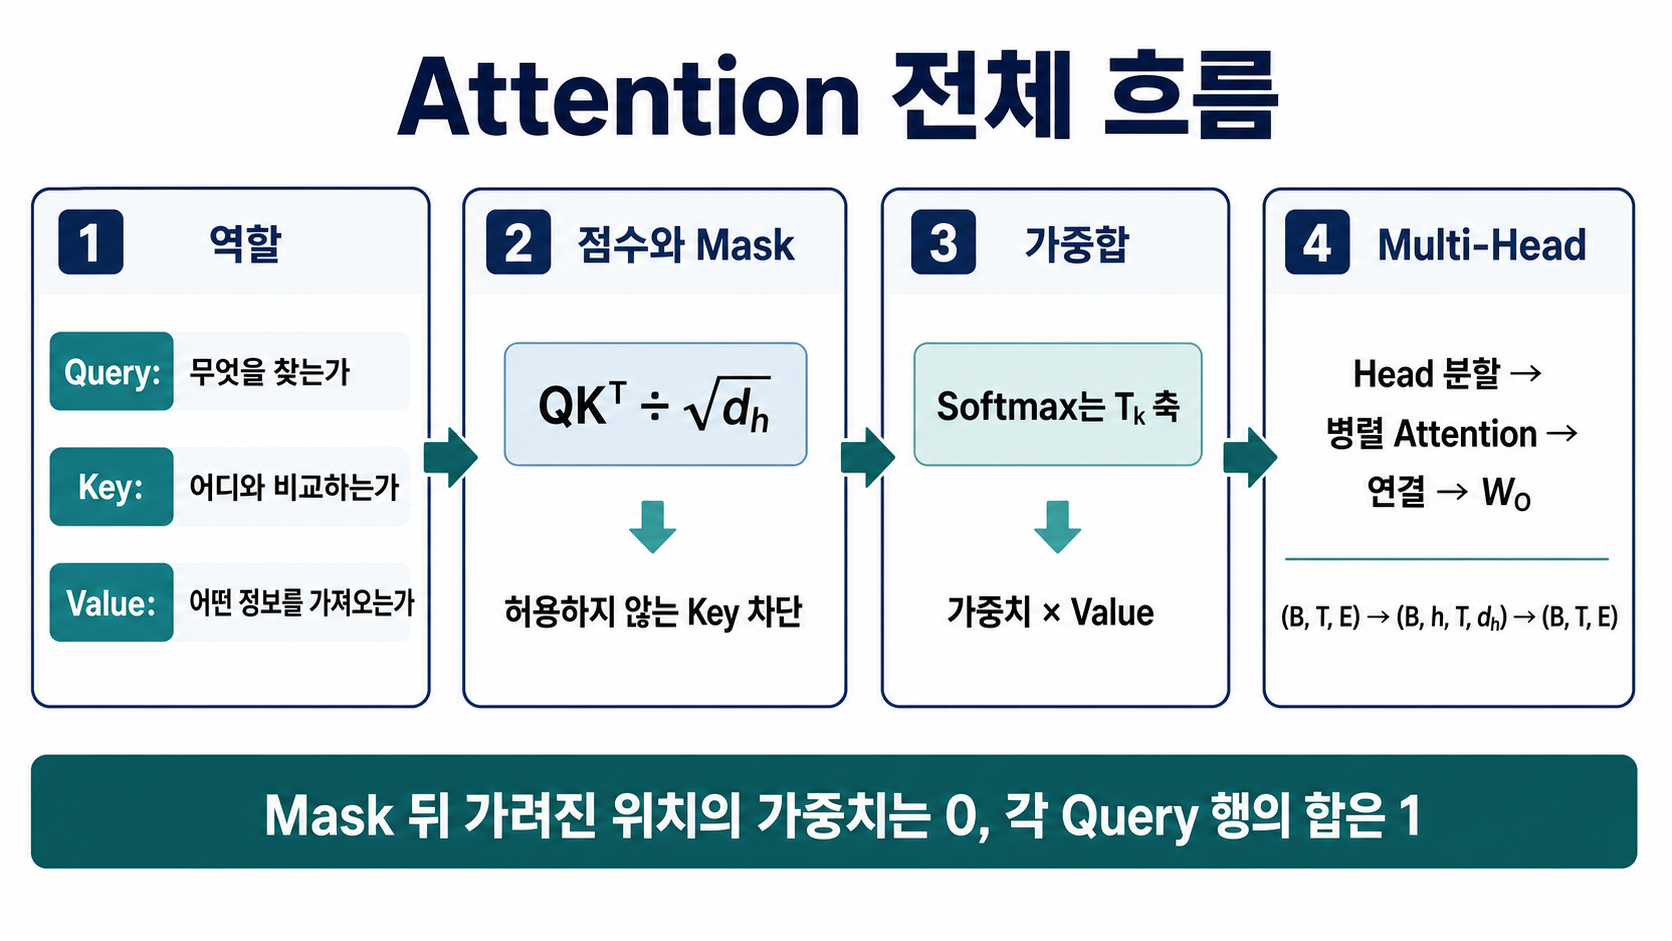

mask 뒤 가려진 Key의 가중치는 0이고, 각 Query 행의 가중치 합은 1이다. Multi-Head의 최종 출력은 head 축이 사라져 다시 `(B, T, E)`가 된다.
